
### link to dataset
https://archive.ics.uci.edu/dataset/381/beijing+pm2+5+data

### link to paper
https://www.semanticscholar.org/paper/Assessing-Beijing's-PM2.5-pollution%3A-severity%2C-APEC-Liang-Zou/8a82cccc111cbe3e7ff7bc16a3345afe8351a425

In [2]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import pyEDM
import math


In [3]:
# @title Uploading dataset
df = pd.read_csv('PRSA_data_2010.1.1-2014.12.31.csv')

In [4]:
df.columns
'''
No:     row number
year:   year of data in this row
month:  month of data in this row
day:    day of data in this row
hour:   hour of data in this row

pm2.5:  PM2.5 concentration (ug/m^3)
        The main pollutants are fine particulate matter, and PM2.5 in particular [1,2].
        PM2.5 consists of airborne particles with aerodynamic diameters of less than 2.5 μm.
        They are known to influence visibility, human health and even climate [3].
        Epidemiological evidence shows that exposure to PM2.5 can cause lung morbidity [4],
        serious respiratory and cardiovascular diseases, and even death


        We first provide a set of descriptive statistics on the extent of the PM2.5 pollution in Beijing.
        According to the US (EPA) standard, 35 μg m−3 (the European Union uses 25 μg m−3) is the highest
        PM2.5 level for acceptable air quality, while 150 μg m−3 is widely viewed as very unhealthy and even hazardous.

        We partition the PM2.5 time series into three states: low PM state when PM2.5 ≤35 μg m−3; polluting episode
        when PM2.5>35 μg m−3; and very high PM when PM2.5>150 μg m−3.


        Wind speed is known to be influential in PM2.5 for studies on the US data

DEWP:   Dew Point (â„ƒ)
        Dew point temperature is the temperature at which air becomes fully saturated with water vapor and must cool to initiate condensation, forming dew, fog, or clouds

TEMP:   Temperature (â„ƒ)
PRES:   Pressure (hPa)
cbwd:   Combined wind direction
Iws:    Cumulated wind speed (m/s)
Is:     Cumulated hours of snow
Ir:     Cumulated hours of rain
'''

'\nNo:     row number\nyear:   year of data in this row\nmonth:  month of data in this row\nday:    day of data in this row\nhour:   hour of data in this row\n\npm2.5:  PM2.5 concentration (ug/m^3)\n        The main pollutants are fine particulate matter, and PM2.5 in particular [1,2].\n        PM2.5 consists of airborne particles with aerodynamic diameters of less than 2.5\u2009μm.\n        They are known to influence visibility, human health and even climate [3].\n        Epidemiological evidence shows that exposure to PM2.5 can cause lung morbidity [4],\n        serious respiratory and cardiovascular diseases, and even death\n\n\n        We first provide a set of descriptive statistics on the extent of the PM2.5 pollution in Beijing.\n        According to the US (EPA) standard, 35\u2009μg\u2009m−3 (the European Union uses 25\u2009μg\u2009m−3) is the highest\n        PM2.5 level for acceptable air quality, while 150\u2009μg\u2009m−3 is widely viewed as very unhealthy and even hazardo

In [5]:
# descriptive statistics and metadata
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      43824 non-null  int64  
 1   year    43824 non-null  int64  
 2   month   43824 non-null  int64  
 3   day     43824 non-null  int64  
 4   hour    43824 non-null  int64  
 5   pm2.5   41757 non-null  float64
 6   DEWP    43824 non-null  int64  
 7   TEMP    43824 non-null  float64
 8   PRES    43824 non-null  float64
 9   cbwd    43824 non-null  object 
 10  Iws     43824 non-null  float64
 11  Is      43824 non-null  int64  
 12  Ir      43824 non-null  int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 4.3+ MB


,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,Iws,Is,Ir
count,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,41757.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000
mean,21912.500000,2012.000000,6.523549,15.727820,11.500000,98.613215,1.817246,12.448521,1016.447654,23.889140,0.052734,0.194916
std,12651.043435,1.413842,3.448572,8.799425,6.922266,92.050387,14.433440,12.198613,10.268698,50.010635,0.760375,1.415867
min,1.000000,2010.000000,1.000000,1.000000,0.000000,0.000000,-40.000000,-19.000000,991.000000,0.450000,0.000000,0.000000
25%,10956.750000,2011.000000,4.000000,8.000000,5.750000,29.000000,-10.000000,2.000000,1008.000000,1.790000,0.000000,0.000000
50%,21912.500000,2012.000000,7.000000,16.000000,11.500000,72.000000,2.000000,14.000000,1016.000000,5.370000,0.000000,0.000000
75%,32868.250000,2013.000000,10.000000,23.000000,17.250000,137.000000,15.000000,23.000000,1025.000000,21.910000,0.000000,0.000000
max,43824.000000,2014.000000,12.000000,31.000000,23.000000,994.000000,28.000000,42.000000,1046.000000,585.600000,27.000000,36.000000


In [6]:
# @title Fixing pm2.5 with linear values with the days before after kind of thing

# The values will be replaced with the linear method as it compares with the days before and after, f and bfill for gaps and edges
df = df.sort_values(['year','month','day','hour']) #just to be sure
df['pm2.5'] = df['pm2.5'].interpolate().bfill().ffill()

df.isna().sum()

No       0
year     0
month    0
day      0
hour     0
pm2.5    0
DEWP     0
TEMP     0
PRES     0
cbwd     0
Iws      0
Is       0
Ir       0
dtype: int64

In [7]:
# EDM specific preprocessing - normalisation and datetime indexing
cols = ['pm2.5', 'TEMP', 'PRES', 'DEWP', 'Iws', 'Is', 'Ir']

df[cols] = sklearn.preprocessing.StandardScaler().fit_transform(df[cols])

In [8]:
#post scaling descriptive statistics and metadata
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      43824 non-null  int64  
 1   year    43824 non-null  int64  
 2   month   43824 non-null  int64  
 3   day     43824 non-null  int64  
 4   hour    43824 non-null  int64  
 5   pm2.5   43824 non-null  float64
 6   DEWP    43824 non-null  float64
 7   TEMP    43824 non-null  float64
 8   PRES    43824 non-null  float64
 9   cbwd    43824 non-null  object 
 10  Iws     43824 non-null  float64
 11  Is      43824 non-null  float64
 12  Ir      43824 non-null  float64
dtypes: float64(7), int64(5), object(1)
memory usage: 4.3+ MB


,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,Iws,Is,Ir
count,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,4.382400e+04,43824.000000,4.382400e+04,4.382400e+04,4.382400e+04,4.382400e+04,4.382400e+04
mean,21912.500000,2012.000000,6.523549,15.727820,11.500000,-4.928920e-17,0.000000,-3.631836e-17,4.851095e-15,-2.723877e-17,-3.048148e-17,-5.739598e-17
std,12651.043435,1.413842,3.448572,8.799425,6.922266,1.000011e+00,1.000011,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00
min,1.000000,2010.000000,1.000000,1.000000,0.000000,-1.080466e+00,-2.897280,-2.578070e+00,-2.478206e+00,-4.686885e-01,-6.935299e-02,-1.376671e-01
25%,10956.750000,2011.000000,4.000000,8.000000,5.750000,-7.505927e-01,-0.818750,-8.565433e-01,-8.226701e-01,-4.418938e-01,-6.935299e-02,-1.376671e-01
50%,21912.500000,2012.000000,7.000000,16.000000,11.500000,-2.777736e-01,0.012662,1.271863e-01,-4.359456e-02,-3.703083e-01,-6.935299e-02,-1.376671e-01
75%,32868.250000,2013.000000,10.000000,23.000000,17.250000,4.149613e-01,0.913358,8.649835e-01,8.328654e-01,-3.957482e-02,-6.935299e-02,-1.376671e-01
max,43824.000000,2014.000000,12.000000,31.000000,23.000000,9.849351e+00,1.814055,2.422555e+00,2.877939e+00,1.123196e+01,3.543986e+01,2.528875e+01


1. System Complexity Analysis

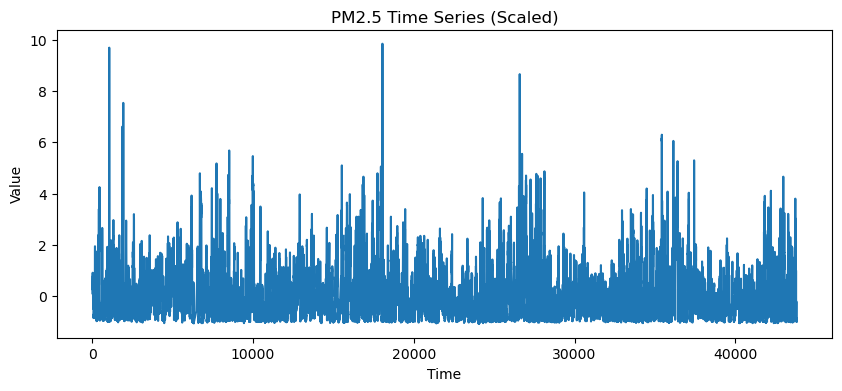

In [27]:
plt.figure(figsize=(10,4))
plt.plot(df['pm2.5'])
plt.title("PM2.5 Time Series (Scaled)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.savefig("pm25_timeseries.png")
plt.show()

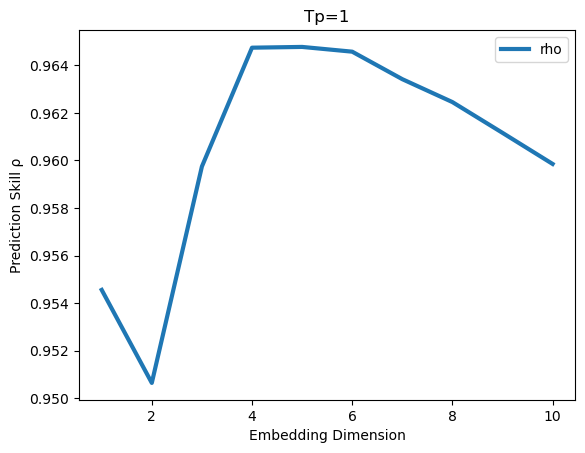

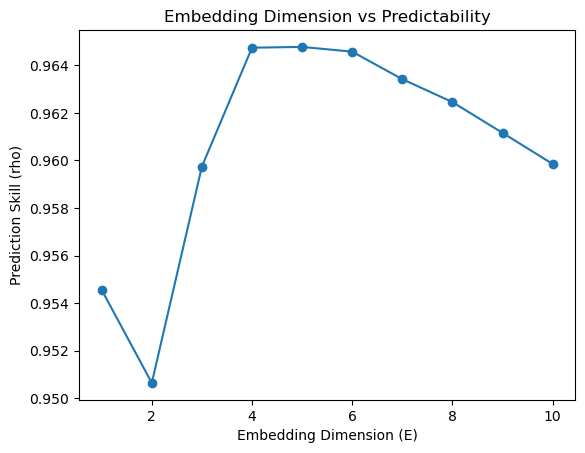

    E       rho
0   1  0.954554
1   2  0.950640
2   3  0.959745
3   4  0.964746
4   5  0.964778
5   6  0.964578
6   7  0.963421
7   8  0.962457
8   9  0.961162
9  10  0.959854


In [8]:
#Finding Embedding dimension - system complexity analysis
E_result = pyEDM.EmbedDimension(

    dataFrame=df,
    lib="1 25000",
    pred="25001 43824",
    columns="pm2.5",
    target="pm2.5",
    Tp=1
)

plt.figure()
plt.plot(E_result['E'], E_result['rho'], marker='o')
plt.xlabel("Embedding Dimension (E)")
plt.ylabel("Prediction Skill (rho)")
plt.title("Embedding Dimension vs Predictability")
plt.savefig(f"embedding_dimension.png")
plt.show()

print(E_result)


In [10]:
simplex_out = pyEDM.Simplex(
    dataFrame=df,
    lib="1 25000",
    pred="25001 43824",
    E= max(E_result['E']),
    columns="pm2.5",
    target="pm2.5"
)
# Compute error

error = pyEDM.ComputeError(

    simplex_out['Observations'],
    simplex_out['Predictions']

)

print(error)

{'rho': np.float64(0.959854), 'MAE': 5.548814, 'CAE': np.float64(3111.626262), 'RMSE': np.float64(0.295647)}


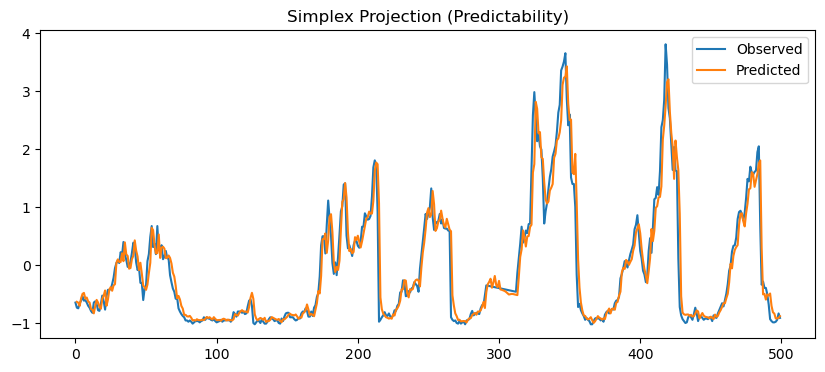

In [11]:
plt.figure(figsize=(10,4))

plt.plot(simplex_out['Observations'][:500], label="Observed")

plt.plot(simplex_out['Predictions'][:500], label="Predicted")

plt.legend()

plt.title("Simplex Projection (Predictability)")

plt.savefig("simplex_prediction.png")

plt.show()

In [15]:
theta_values = [0, 0.5, 1, 2, 4, 6, 8]
results = []
for theta in theta_values:
    theta_result = pyEDM.SMap(
        dataFrame=df,
        lib="1 25000",
        pred="25001 43824",
        E= max(E_result['E']),
        theta=theta,
        columns="pm2.5",
        target="pm2.5"

    )

    pred_df = theta_result['predictions']
    #coef_df = theta_result['coefficients']

    error = pyEDM.ComputeError(pred_df['Observations'], pred_df['Predictions'])

    results.append({
            "theta": theta,
            "rho": error["rho"],
            "MAE": error["MAE"],
            "RMSE": error["RMSE"]
        })

results_df = pd.DataFrame(results)

print(results_df)

   theta       rho       MAE      RMSE
0    0.0  0.971336  5.458054  0.250013
1    0.5  0.971593  5.463697  0.248769
2    1.0  0.971705  5.460770  0.248272
3    2.0  0.971830  5.455294  0.247726
4    4.0  0.971864  5.450167  0.247572
5    6.0  0.971629  5.447434  0.248584
6    8.0  0.971048  5.444795  0.251078


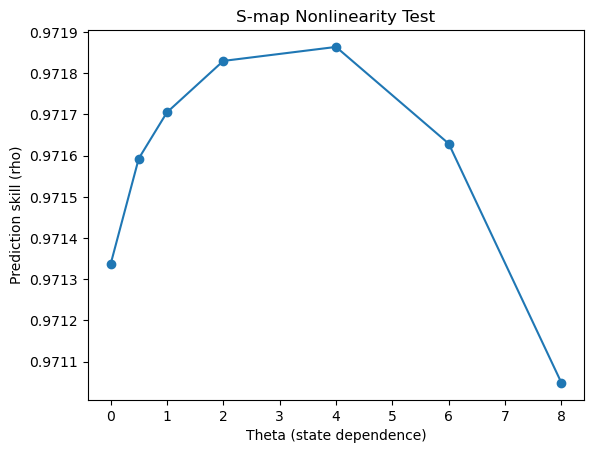

In [16]:


plt.figure()

plt.plot(results_df["theta"], results_df["rho"], marker="o")

plt.xlabel("Theta (state dependence)")

plt.ylabel("Prediction skill (rho)")

plt.title("S-map Nonlinearity Test")

plt.savefig("theta_vs_rho.png")

plt.show()

2. Comparing FNNs, Cao and Simplex/S-map

In [13]:

from nolitsa import dimension

# time series
x = df["pm2.5"].values

# FNN computation
dims = np.arange(1, 11)
fnn_vals = dimension.fnn(x, tau=1, dim=dims, R=10.0, A=2.0, maxnum=5000)


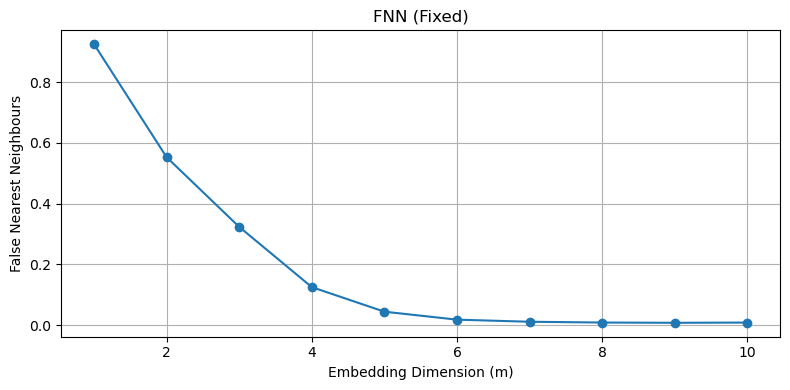

[(np.int64(1), np.float64(0.9246058006069872)), (np.int64(2), np.float64(0.5526904294646524)), (np.int64(3), np.float64(0.3234750462107209)), (np.int64(4), np.float64(0.1252852578731173)), (np.int64(5), np.float64(0.044478422602067594)), (np.int64(6), np.float64(0.018257337167374137)), (np.int64(7), np.float64(0.011342629572996782)), (np.int64(8), np.float64(0.008763921855030126)), (np.int64(9), np.float64(0.007919662216136027)), (np.int64(10), np.float64(0.008673026886383347))]


In [ ]:
fnn_vals = np.array(fnn_vals)

# was getting shape output error which i took Chatgpt 4-o to debug

if fnn_vals.ndim == 2:

    fnn_vals = fnn_vals[-1]

plt.figure(figsize=(8,4))

plt.plot(dims, fnn_vals, marker='o')

plt.xlabel("Embedding Dimension (m)")

plt.ylabel("False Nearest Neighbours")

plt.title("FNN (Fixed)")

plt.grid()

plt.tight_layout()

plt.savefig("fnn_fixed.png")

plt.show()

print(list(zip(dims, fnn_vals)))

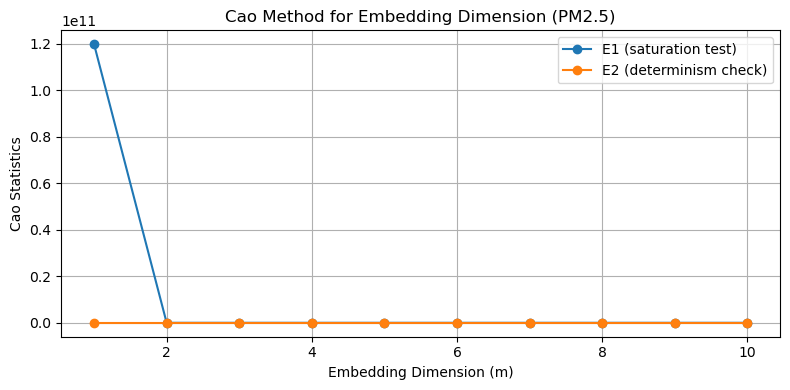

m=1, E1=119851900447.5514, E2=0.1456
m=2, E1=22.2244, E2=0.1862
m=3, E1=11.6135, E2=0.1930
m=4, E1=6.8074, E2=0.1935
m=5, E1=4.4558, E2=0.1959
m=6, E1=3.3195, E2=0.1975
m=7, E1=2.7066, E2=0.2003
m=8, E1=2.3418, E2=0.2053
m=9, E1=2.0855, E2=0.2094
m=10, E1=1.9098, E2=0.2139


In [21]:
x = df["pm2.5"].values.astype(float)


dims = np.arange(1, 11)

E1, E2 = dimension.afn(x, tau=1, dim=dims, maxnum=1000)


plt.figure(figsize=(8,4))
plt.plot(dims, E1, marker='o', label="E1 (saturation test)")
plt.plot(dims, E2, marker='o', label="E2 (determinism check)")
plt.xlabel("Embedding Dimension (m)")
plt.ylabel("Cao Statistics")
plt.title("Cao Method for Embedding Dimension (PM2.5)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("cao_method.png")
plt.show()


for i, m in enumerate(dims):

    print(f"m={m}, E1={E1[i]:.4f}, E2={E2[i]:.4f}")

Q3. uni/multivariat/multi-view

In [8]:
lib = "1 30000"
pred = "30001 43824"
E = 5  

uni = pyEDM.SMap(
    dataFrame=df,
    lib=lib,
    pred=pred,
    E=E,
    columns="pm2.5",
    target="pm2.5"
)

uni_metrics = pyEDM.ComputeError(
    uni["predictions"]["Observations"],
    uni["predictions"]["Predictions"]
)

In [9]:
multi = pyEDM.SMap(
    dataFrame=df,
    lib=lib,
    pred=pred,
    embedded=True,
    E=E,
    columns="pm2.5 TEMP DEWP PRES Iws Is Ir",
    target="pm2.5"
)

multi_metrics = pyEDM.ComputeError(
    multi["predictions"]["Observations"],
    multi["predictions"]["Predictions"]
)

In [10]:
corr = df[["pm2.5","TEMP","DEWP","PRES","Iws","Is","Ir"]].corr()

print(corr["pm2.5"].sort_values(ascending=False))

pm2.5    1.000000
DEWP     0.168500
Is       0.019300
PRES    -0.048006
Ir      -0.050247
TEMP    -0.089358
Iws     -0.245688
Name: pm2.5, dtype: float64


In [11]:
mv = pyEDM.SMap(
    dataFrame=df,
    lib=lib,
    pred=pred,
    embedded=True,
    E=E,
    columns="pm2.5 DEWP Iws",
    target="pm2.5"
)

mv_metrics = pyEDM.ComputeError(
    mv["predictions"]["Observations"],
    mv["predictions"]["Predictions"]
)

          Model       rho       MAE      RMSE
0    Univariate  0.972023  5.478139  0.229354
1  Multivariate  0.970858  5.519891  0.233976
2     Multiview  0.970900  5.486514  0.233857


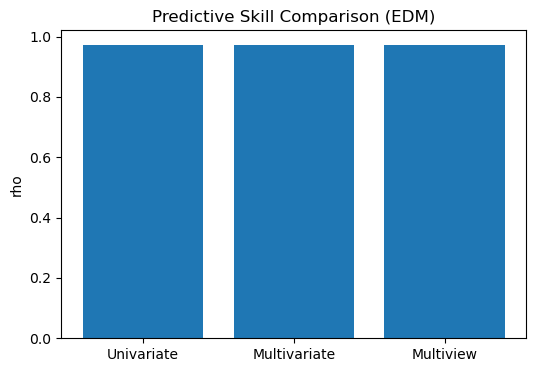

In [12]:
results = pd.DataFrame([
    ["Univariate", uni_metrics["rho"], uni_metrics["MAE"], uni_metrics["RMSE"]],
    ["Multivariate", multi_metrics["rho"], multi_metrics["MAE"], multi_metrics["RMSE"]],
    ["Multiview", mv_metrics["rho"], mv_metrics["MAE"], mv_metrics["RMSE"]],
], columns=["Model", "rho", "MAE", "RMSE"])

print(results)

plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["rho"])
plt.title("Predictive Skill Comparison (EDM)")
plt.ylabel("rho")
plt.savefig("embedding_comparison.png")
plt.show()